# Введение

В этом ноутбуке мы решаем задачу прогнозирования розничного товарооборота (РТО) магазинов сети «Пятёрочка». РТО — это сумма выручки магазина за месяц.

В рамках хакатона вы будете работать с классической задачей, с которой сталкиваются операционный и финансовый департаменты X5 Retail Group. Компании важно заранее понимать, какой будет выручка каждого магазина в следующем месяце, чтобы корректно поставить финансовый план, распределить ресурсы и принять управленческие решения.

Ваша задача как аналитика данных — научиться как можно точнее предсказывать значение РТО, используя исторические данные, а также характеристики магазина и его окружения.

Каждая строка в данных соответствует одному магазину в один месяц. У каждого магазина есть уникальный идентификатор new_id, который позволяет проследить, как меняется РТО конкретного магазина со временем. Помимо самого РТО, в данных присутствуют признаки, описывающие магазин: регион, населённый пункт, параметры района, инфраструктура вокруг магазина и другие характеристики.

Машинное обучение - это подход, при котором мы не задаём формулу для расчёта РТО вручную. Вместо этого мы показываем алгоритму примеры из прошлого: какие были характеристики магазина и каким был фактический РТО. На основе этих примеров модель пытается найти зависимости между признаками и целевой переменной и затем использует найденные закономерности для прогнозирования будущих значений.

Например, модель может заметить, что магазины с определёнными характеристиками района или инфраструктуры стабильно показывают более высокий РТО, или что для конкретного магазина значения РТО в прошлые месяцы хорошо помогают предсказать продажи в следующем месяце. Важно, что все такие зависимости модель извлекает автоматически из данных, без явных правил, заданных человеком.

В этом ноутбуке мы будем постепенно усложнять подход к прогнозированию. Сначала мы построим простой базовый прогноз, который опирается только на динамику РТО в прошлые месяцы, затем мы усложним подход, используя модели машинного обучения.

В конце мы сравним все построенные модели между собой и посмотрим, как усложнение алгоритма влияет на качество прогноза.

# Знакомство с Python и библиотеками для анализа данных

Для работы с данными мы будем использовать язык программирования Python и несколько библиотек, которые сильно упрощают анализ данных и построение моделей машинного обучения.

Библиотека — это готовый набор инструментов (функций и классов), которые кто-то уже написал за нас.

В этом ноутбуке мы будем использовать несколько основных библиотек:

pandas — для работы с таблицами и данными  
numpy — для числовых вычислений  
matplotlib и seaborn — для построения графиков  

Перед тем как использовать библиотеку, её нужно импортировать.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

После импорта библиотек мы можем работать с данными. Основной объект в pandas — это таблица, которая называется DataFrame. Она похожа на таблицу в Excel: у неё есть строки и столбцы.

Теперь загрузим данные из файла.

In [2]:
df = pd.read_csv('./train.csv')

### Базовые возможности работы с таблицами DataFrame

Посмотрим на первые несколько строк таблицы, чтобы понять, как выглядят данные.

In [3]:
df.head()

,new_id,Месяц,"Дата открытия, категориальный","Торговая площадь, категориальный",Населенный пункт,Регион,Численность населения,Количество домохозяйств,"Трафик пеший, в час","Трафик авто, в час","Маркетплейсы, доставки, постаматы (100 м)",Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО
0,0,1,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,0,6,0,0,2,0,10,1,22041969.33
1,0,2,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,0,6,0,0,2,0,10,1,23268490.57
2,0,3,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,0,6,0,0,2,0,10,1,24487732.21
3,0,4,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,0,6,0,0,2,0,10,1,23981980.29
4,0,5,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,0,6,0,0,2,0,10,1,26608343.78


Посмотрим на размер таблицы: сколько строк и сколько столбцов в данных.

In [4]:
df.shape

(206150, 19)

Также полезно посмотреть список столбцов и их типы. Тип данных показывает, является ли столбец числовым, категориальным или текстовым. Это позволит нам понять, какие признаки являются бинарными (принимают одно из двух значений), числовыми (могут использоваться моделями напрямую), либо категориальными (требуют предобработки, о ней позже). Также информация о датафрейме показывает, сколько не NaN значений в датафрейме, это позволяет понять, насколько полны наши данные. Данная информация может быть полезна для предобработки данных перед обучением моделей машинного обучения. Подробнее в [статье](https://habr.com/ru/articles/800973/).

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206150 entries, 0 to 206149
Data columns (total 19 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   new_id                                     206150 non-null  int64  
 1   Месяц                                      206150 non-null  int64  
 2   Дата открытия, категориальный              206150 non-null  object 
 3   Торговая площадь, категориальный           206150 non-null  object 
 4   Населенный пункт                           206150 non-null  object 
 5   Регион                                     206150 non-null  object 
 6   Численность населения                      206150 non-null  int64  
 7   Количество домохозяйств                    206150 non-null  int64  
 8   Трафик пеший, в час                        206150 non-null  int64  
 9   Трафик авто, в час                         206150 non-null  int64  
 10  Маркетпл

#### Работа с отдельными столбцами

Обратиться к конкретному столбцу можно по его названию. Например, посмотрим на столбец с РТО.

In [6]:
df["РТО"].head()

0    22041969.33
1    23268490.57
2    24487732.21
3    23981980.29
4    26608343.78
Name: РТО, dtype: float64

Мы можем посчитать простые статистики: среднее значение, минимальное и максимальное, стандартное отклонение.

In [7]:
df["РТО"].describe().map('{:.2f}'.format)

count       206150.00
mean      32727246.59
std       17689090.38
min          16194.87
25%       20864322.68
50%       27918452.74
75%       39233284.55
max      220587049.12
Name: РТО, dtype: object

### Фильтрация данных

Часто нужно работать не со всеми данными сразу, а только с их частью. В данном ноутбуке будем делать предсказание на август, **участникам для отправки решения первого этапа нужно построить модель, которая предскажет РТО магазинов на ноябрь.**

In [8]:
df = df[df['Месяц'] <= 8]

### С большим функционалом pandas можно также ознакомиться в [документации](https://pandas.pydata.org/docs/user_guide/basics.html)

Если возникают сложности с чтением документации на английском языке, предлагается воспользоваться браузером со встроенными переводчиком страниц. Кроме того, можно найти в сети ресурсы с демонстрацией функционала библиотеки на русском языке (например, см. статью на [Хабре](https://habr.com/ru/companies/ruvds/articles/494720/), но имейте в виду, что часть информации может быть устаревшей). Или задать интересующий вопрос языковым моделям (например, обратиться к [deepseek](https://chat.deepseek.com/))

## Визуализация данных

Перед тем как строить модели, полезно посмотреть на данные глазами. Начнём с простого графика — как меняется РТО со временем.

Построим средний РТО по каждому месяцу.

Подробнее с визуализацией данных можно ознакомиться по [ссылке](https://habr.com/ru/articles/984144/).

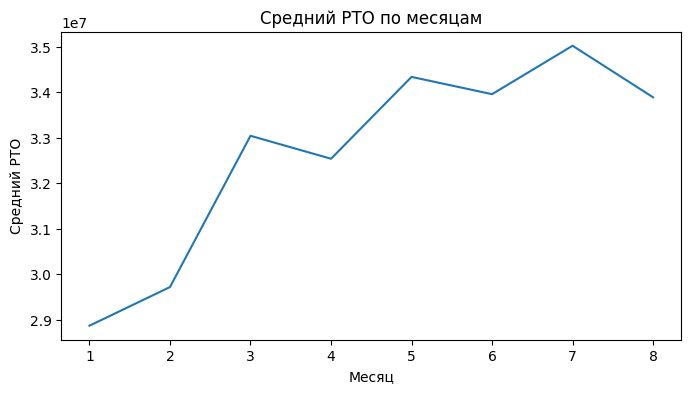

In [9]:
mean_rto_by_month = df.groupby("Месяц")["РТО"].mean()

plt.figure(figsize=(8, 4))
plt.plot(mean_rto_by_month.index, mean_rto_by_month.values)
plt.xlabel("Месяц")
plt.ylabel("Средний РТО")
plt.title("Средний РТО по месяцам")
plt.show()

Также полезно посмотреть распределение РТО — какие значения встречаются чаще, а какие реже. Это помогает понять, с какими значениями выручки модель будет сталкиваться чаще всего, и проверить, нет ли выбросов, которые могут ухудшить качество предсказаний.

/home/local/X5/andrey.meneylyuk/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


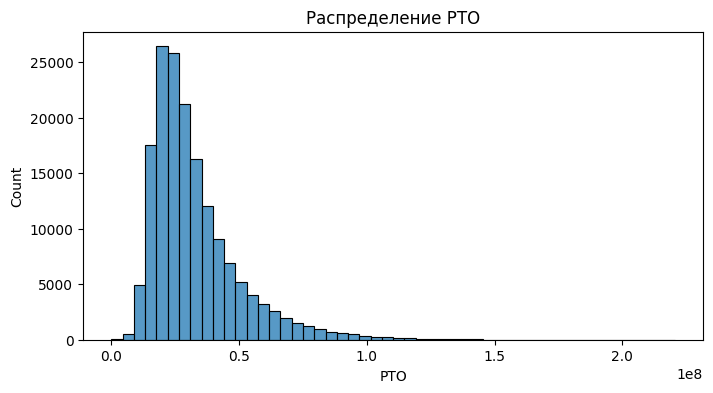

In [10]:
plt.figure(figsize=(8, 4))
sns.histplot(df["РТО"], bins=50)
plt.xlabel("РТО")
plt.title("Распределение РТО")
plt.show()

На этом этапе мы познакомились с данными, научились читать файл, смотреть на структуру таблицы и строить простые графики.

Дальше мы начнём строить первый прогноз. Он будет максимально простым и не будет использовать машинное обучение — мы попробуем оценить средний прирост РТО по месяцам и использовать его для предсказания следующего месяца.

# Базовый прогноз: средний месячный прирост РТО

Перед тем как использовать модели машинного обучения, полезно построить простой базовый прогноз. Такой прогноз позволяет понять, насколько вообще сложна задача и какой уровень качества можно получить без сложных алгоритмов.

Идея базового прогноза следующая. У каждого магазина есть история РТО за предыдущие месяцы. Мы можем посмотреть, как в среднем меняется РТО от месяца к месяцу, и использовать этот средний темп роста для прогнозирования следующего месяца.

Если обозначить РТО в месяце t как $RTO_t$ , то для каждого магазина можно посчитать относительный прирост между месяцами как:

$$(RTO_t − RTO_{t−1}) / RTO_{t−1}$$

После этого мы усредняем такие приросты по всем доступным месяцам и используем средний коэффициент роста для прогноза следующего месяца.

## Подготовка данных для базового прогноза

Для расчёта прироста нам важно, чтобы данные каждого магазина были отсортированы по месяцам. Отложим один месяц для оценки качества базовой модели.

In [11]:
df_train = df[df["Месяц"] <= 7].copy()
df_test = df[df["Месяц"] == 8].copy()
df_train = df_train.sort_values(["new_id", "Месяц"])

## Расчёт месячного прироста РТО

Для каждого магазина посчитаем относительное изменение РТО по сравнению с предыдущим месяцем.

In [12]:
df_train["rto_growth"] = (
    df_train.groupby("new_id")["РТО"]
    .pct_change()
)

Посмотрим на полученные значения прироста.

In [13]:
df_train[['new_id', 'Месяц', 'РТО', 'rto_growth']].head(24)

,new_id,Месяц,РТО,rto_growth
0,0,1,22041969.33,NaN
1,0,2,23268490.57,0.055645
2,0,3,24487732.21,0.052399
3,0,4,23981980.29,-0.020653
4,0,5,26608343.78,0.109514
5,0,6,26148681.55,-0.017275
6,0,7,27292985.79,0.043761
10,1,1,21881376.19,NaN
11,1,2,24370168.15,0.113740
12,1,3,26457212.23,0.085639


Пример расчета прироста для магазина 0 в феврале:

1) **РТО** для магазина 0 в январе = 22041969.33, в феврале = 23268490.57

2) Прирост = (23268490.57 - 22041969.33) / 22041969.33 ~ 0.055645

Первый месяц для каждого магазина не имеет предыдущего значения, поэтому прирост для него равен NaN (пропущенному значению). Такие значения мы не будем учитывать при расчёте среднего.

In [14]:
mean_growth = df_train["rto_growth"].mean()
mean_growth

0.05559029823060929

## Прогноз РТО на следующий месяц

Теперь используем полученный средний прирост для прогнозирования РТО на следующий месяц.

Для каждого магазина мы берём значение РТО за текущий (известный) месяц и умножаем его на (1 + средний прирост), чтобы предсказать РТО следующего месяца.

In [15]:
# данные за 7-й месяц
rto_month_7 = df_train[df_train["Месяц"] == 7].copy()

In [16]:
# считаем прогноз на 8-й месяц
rto_month_7["rto_pred_baseline"] = rto_month_7["РТО"] * (1 + mean_growth)

rto_month_7[['new_id', 'Месяц', 'РТО', 'rto_growth', 'rto_pred_baseline']].head()

,new_id,Месяц,РТО,rto_growth,rto_pred_baseline
6,0,7,27292985.79,0.043761,2.881021e+07
16,1,7,19449307.26,-0.209160,2.053050e+07
26,2,7,40575848.22,0.005351,4.283147e+07
36,3,7,59435829.60,0.019141,6.273989e+07
46,4,7,37294028.76,-0.056961,3.936721e+07


Теперь у нас есть базовый прогноз РТО для 8-го месяца. Чтобы понять, насколько он хороший, нужно сравнить его с реальными значениями РТО за 8-й месяц и посчитать метрику качества.

В следующем шаге мы познакомимся с метрикой MAPE и научимся измерять ошибку наших прогнозов.

# Метрика качества прогнозов: MAPE

После того как мы построили базовый прогноз, нужно понять, насколько он точный. Для этого используют метрики качества. В задачах регрессии одной из самых популярных метрик является MAPE (Mean Absolute Percentage Error) — средняя абсолютная процентная ошибка.

Идея метрики достаточно интуитивна.

Для каждого магазина мы сравниваем фактическое значение РТО и предсказанное моделью. Сначала считаем ошибку прогноза — разницу между реальным и предсказанным значением:
​
$$error_i = RTOreal_{i} - RTOpred_{i}$$

Однако сама по себе такая ошибка не всегда удобна для интерпретации. Например, ошибка в 100 тысяч рублей может быть большой для маленького магазина и незначительной для крупного. Поэтому в MAPE ошибку нормируют — делят на фактическое значение показателя. Таким образом мы получаем относительную (процентную) ошибку:

$$\frac{|RTOreal_{i} - RTOpred_{i}|}{RTOreal_{i}}$$

Берётся модуль ошибки, потому что нам важно только величина отклонения, а не его знак — модель могла как завысить, так и занизить прогноз.

После этого относительные ошибки усредняются по всем наблюдениям. Получаем среднюю процентную ошибку прогноза:

$$MAPE = \frac{1}{n} \sum_{i=1}^{n} \frac{|RTOreal_{i} - RTOpred_{i}|}{RTOreal_{i}} \times 100\%$$

Главное преимущество MAPE — интерпретируемость. Результат сразу выражается в процентах. Например, если MAPE=8%, это означает, что в среднем прогноз отклоняется от фактического значения примерно на 8%.

Интерпретация метрики простая: чем меньше значение MAPE, тем точнее прогноз.

In [17]:
from sklearn.metrics import mean_absolute_percentage_error

# реальные значения за 8-й месяц
df_test = df[df["Месяц"] == 8][["new_id", "РТО"]].copy()

# соединяем с прогнозом
df_eval = df_test.merge(rto_month_7[["new_id", "rto_pred_baseline"]], on="new_id")

# вычисляем MAPE
mape_baseline = mean_absolute_percentage_error(df_eval["РТО"], df_eval["rto_pred_baseline"]) * 100
print(f"Наш прогноз отклоняется от фактических данных на {round(mape_baseline,4)} %") 

Наш прогноз отклоняется от фактических данных на 9.7062 %


При дальнейшем построении моделей машинного обучения мы будем стремиться уменьшить MAPE, чтобы прогноз был ближе к реальным значениям.

# Лаговые признаки: как использовать прошлые значения РТО

До этого момента мы использовали только одну идею: средний рост РТО от месяца к месяцу. Теперь мы сделаем важный шаг вперёд и начнём использовать историю продаж конкретного магазина как признаки для модели.

Интуиция здесь простая. Чтобы предсказать РТО в будущем, полезно знать, каким он был в прошлом. Например, значение РТО в прошлом месяце часто является хорошей подсказкой для прогноза следующего месяца.

Признаки, которые содержат значения целевой переменной из прошлых моментов времени, называются лаговыми признаками.

## Пример лаговых признаков

Для каждого магазина мы можем создать:
- РТО за предыдущий месяц (лаг 1),
- РТО за два месяца назад (лаг 2),
- среднее РТО за несколько последних месяцев.

Такие признаки позволяют модели учитывать динамику продаж конкретного магазина, а не только общие закономерности.

## Подготовка данных

Мы будем создавать лаговые признаки внутри каждого магазина, поэтому сначала отсортируем данные по new_id и месяцу.

In [18]:
# сортируем данные
df = df.sort_values(["new_id", "Месяц"]).copy()

## Создание лаговых признаков

Начнём с самых простых лагов: РТО за 1 и 2 месяца назад.

In [19]:
df["rto_lag_1"] = df.groupby("new_id")["РТО"].shift(1)
df["rto_lag_2"] = df.groupby("new_id")["РТО"].shift(2)

Также часто полезно добавить агрегированные признаки, например среднее РТО за несколько предыдущих месяцев.

In [20]:
# средний РТО за последние 3 месяца
df["rto_mean_3"] = (
    df.groupby("new_id")["РТО"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

Посмотрим, как теперь выглядит таблица.

In [21]:
df[['new_id', 'Месяц', 'РТО', 'rto_lag_1', 'rto_lag_2', 'rto_mean_3']].head(5)

,new_id,Месяц,РТО,rto_lag_1,rto_lag_2,rto_mean_3
0,0,1,22041969.33,NaN,NaN,NaN
1,0,2,23268490.57,22041969.33,NaN,NaN
2,0,3,24487732.21,23268490.57,22041969.33,NaN
3,0,4,23981980.29,24487732.21,23268490.57,2.326606e+07
4,0,5,26608343.78,23981980.29,24487732.21,2.391273e+07


Для первых месяцев у магазина не хватает истории, поэтому лаговые признаки будут равны NaN. Такие строки нельзя использовать для обучения модели, и мы будем их удалять.

In [22]:
df_model = df.dropna(subset=["rto_lag_1", "rto_lag_2", "rto_mean_3"]).copy()

Теперь мы снова разделим данные на обучающую выборку (первые 7 месяцев) и тестовую выборку (8-й месяц).

In [23]:
train_data = df_model[df_model["Месяц"] <= 7].copy()
test_data = df_model[df_model["Месяц"] == 8].copy()

Мы подготовили данные для машинного обучения: у нас есть целевая переменная РТО и признаки, которые содержат информацию о прошлых значениях продаж.

# Линейная регрессия

Теперь, когда у нас есть лаговые признаки, мы можем обучить первую модель машинного обучения — линейную регрессию.

Линейная регрессия пытается предсказать РТО как линейную комбинацию признаков. Проще говоря, модель подбирает веса для каждого признака так, чтобы итоговый прогноз был как можно ближе к реальному РТО на обучающих данных. 

Линейная регрессия — хороший первый алгоритм, потому что:
- она проста в использовании,
- быстро обучается,
- позволяет понять, какие признаки важны для прогноза.

### В основе любого алгоритма машинного обучения лежит прочная математическая база. В этом ноутбуке мы не будем углубляться в теоретические основы моделей, а предлагаем участникам самостоятельно изучить принципы работы различных алгоритмов. Более подробную информацию о модели линейной регрессии вы можете найти в соответствующих [материалах](https://habr.com/ru/articles/514818/).

In [24]:
# целевая переменная
target = "РТО"

# категориальные признаки
categorical_features = [
    "Дата открытия, категориальный",
    "Торговая площадь, категориальный",
    "Регион",
]

# числовые признаки
numeric_features = [
    "Месяц",
    "rto_lag_1",
    "rto_lag_2",
    "rto_mean_3",
    'Численность населения', 'Количество домохозяйств',
    'Трафик пеший, в час', 'Трафик авто, в час',
    'Маркетплейсы, доставки, постаматы (100 м)',
    'Медицинские уч. и аптеки (300 м)', 'Школы (300 м)',
    'Остановки (300 м)', 'Продуктовые магазины (500 м)',
    'Пятерочки (500 м)', 'Количество касс', 'Флаг алкогольной лицензии'
]

## Подготовка признаков и целевой переменной

Целевая переменная — это РТО. В качестве признаков мы будем использовать лаговые признаки и характеристики магазина.

Перед обучением модели категориальные признаки нужно закодировать числовым способом, так как линейная регрессия умеет работать только с числами.
Для этого мы будем использовать [one-hot](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) кодирование.

One-hot это не единственный способ преобразовать категориальную переменную, с различными видами категориальных кодировщиков можно ознакомиться по [ссылке](https://habr.com/ru/articles/666234/).

In [25]:
from sklearn.preprocessing import OneHotEncoder

# создаём кодировщик
ohe = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore"
)

# обучаем кодировщик на train
ohe.fit(train_data[categorical_features])

# кодируем категориальные признаки
X_train_cat = ohe.transform(train_data[categorical_features])
X_test_cat = ohe.transform(test_data[categorical_features])

Объединим закодированные категориальные признаки с числовыми.

In [26]:
# числовые признаки
X_train_num = train_data[numeric_features].values
X_test_num = test_data[numeric_features].values

# итоговые матрицы признаков
X_train = np.hstack([X_train_num, X_train_cat])
X_test = np.hstack([X_test_num, X_test_cat])

# целевая переменная
y_train = train_data[target].values
y_test = test_data[target].values

## Обучение линейной регрессии

На этом этапе мы обучим модель линейной регрессии, сделаем прогноз для тестовых данных и оценим качество полученного решения.

Импортируем класс LinearRegression, который реализует модель линейной регрессии, а также функцию mean_absolute_percentage_error для вычисления метрики качества прогноза

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

Создаём объект модели линейной регрессии и обучаем его на тренировочной выборке (X_train, y_train).
В процессе обучения модель подбирает коэффициенты при признаках, минимизируя ошибку прогноза на обучающих данных

In [28]:
# обучаем модель
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

Используем обученную модель для предсказания значений целевой переменной (РТО) для объектов из тестовой выборки X_test.

In [29]:
# прогноз на 8-й месяц
y_pred_lr = lr_model.predict(X_test)

# MAPE
mape_lr = mean_absolute_percentage_error(y_test, y_pred_lr) * 100
print(f"Наш прогноз отклоняется от фактических данных на {round(mape_lr,4)} %")

Наш прогноз отклоняется от фактических данных на 9.7163 %


# Случайный лес

Линейная регрессия предполагает, что связь между признаками и РТО можно описать линейной формулой. Однако в реальных данных такие зависимости часто бывают сложнее: влияние признаков может зависеть друг от друга, а эффект изменения одного признака может быть разным в разных ситуациях.

Случайный лес — это алгоритм машинного обучения, который состоит из большого количества решающих деревьев. Каждое дерево строит набор простых правил вида «если — то» и делает собственный прогноз РТО. Итоговый прогноз случайного леса получается как усреднение прогнозов всех деревьев.

Ключевая идея случайного леса заключается в том, что:
- каждое дерево обучается на случайной подвыборке данных;
- на каждом шаге дерево рассматривает только случайное подмножество признаков;
- за счёт этого деревья получаются разными и допускают разные ошибки.

Когда мы усредняем прогнозы большого количества разных деревьев, случайные ошибки компенсируют друг друга, и итоговый прогноз становится более устойчивым и точным.

Подробнее ознакомиться со случайным лесом и другими ансамблевыми методами можно  по ссылкам: [1](https://www.hse.ru/mirror/pubs/share/215285958) и [2](https://habr.com/ru/companies/ods/articles/324402/).

## Подготовка данных

Для случайного леса мы будем использовать те же числовые признаки, что и для линейной регрессии. Кодирование категориальных признаков же мы проведём по-другому: использование one-hot кодирование для Случайного леса является не очень хорошей идеей, так как при таком кодировании один категориальный признак делится на несколько, и деревья менее эффективно находят взаимосвязи в данных. Поэтому мы просто закодируем каждую категорию каким-то числом с помощью [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html).

In [30]:
from sklearn.preprocessing import OrdinalEncoder

# кодируем категориальные признаки
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
oe.fit(train_data[categorical_features])

X_train_cat = oe.transform(train_data[categorical_features])
X_test_cat = oe.transform(test_data[categorical_features])

# числовые признаки берём такими, какие есть
X_train_num = train_data[numeric_features].values
X_test_num = test_data[numeric_features].values

X_train = np.hstack([X_train_num, X_train_cat])
X_test = np.hstack([X_test_num, X_test_cat])

## Обучение модели случайного леса

Мы начнём с простых настроек модели. Основные параметры:
- n_estimators — количество деревьев в лесу;
- max_depth — максимальная глубина каждого дерева;
- random_state — фиксирует случайность, чтобы результаты можно было воспроизвести.

In [31]:
from sklearn.ensemble import RandomForestRegressor

In [32]:
# создаём модель случайного леса
rf_model = RandomForestRegressor(
    n_estimators=1000,
    max_depth=5,
    random_state=41,
    n_jobs=-1
)

# обучаем модель
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, n_estimators=1000, n_jobs=-1,
                      random_state=41)

## Оценка качества модели (MAPE)

In [33]:
# прогноз на 8-й месяц
y_pred_rf = rf_model.predict(X_test)

# MAPE
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf) * 100
print(f"Наш прогноз отклоняется от фактических данных на {round(mape_rf, 4)} %")

Наш прогноз отклоняется от фактических данных на 7.5126 %


## Визуализация прогнозов

Отобразим ещё раз на графике среднее РТО магазинов по месяцам, и добавим наши прогнозы.

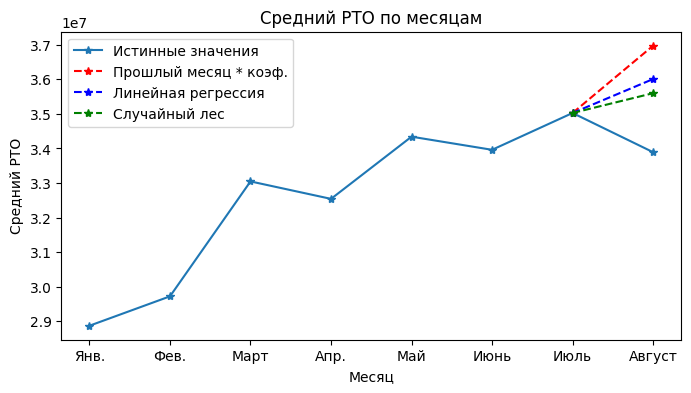

In [34]:
mean_rto_by_month = df.groupby("Месяц")["РТО"].mean()

plt.figure(figsize=(8, 4))
plt.plot(mean_rto_by_month.index, mean_rto_by_month.values, '*-')
oct_value = mean_rto_by_month.values[-2]
plt.plot([7, 8], [oct_value, df_eval['rto_pred_baseline'].mean()], 'r*--')
plt.plot([7, 8], [oct_value, y_pred_lr.mean()], 'b*--')
plt.plot([7, 8], [oct_value, y_pred_rf.mean()], 'g*--')
plt.legend(['Истинные значения', 'Прошлый месяц * коэф.', 'Линейная регрессия', 'Случайный лес'])
plt.xticks(mean_rto_by_month.index, labels=['Янв.', 'Фев.', 'Март', 'Апр.', 'Май', 'Июнь', 'Июль', 'Август'])
plt.xlabel("Месяц")
plt.ylabel("Средний РТО")
plt.title("Средний РТО по месяцам")
plt.show()

Отобразим на графике предсказания наших моделей. По оси X отложены реальные значения РТО, а по оси Y — предсказанные. Чёрная пунктирная диагональная линия — это линия идеального прогноза: если бы модель предсказывала абсолютно точно, все точки лежали бы прямо на ней. 

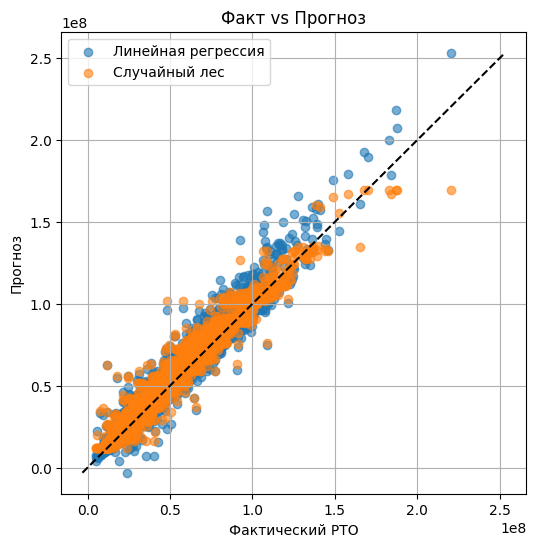

In [35]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 6))


# фактические значения
plt.scatter(y_test, y_pred_lr, alpha=0.6, label="Линейная регрессия")
plt.scatter(y_test, y_pred_rf, alpha=0.6, label="Случайный лес")


# линия идеального прогноза
min_val = min(y_test.min(), y_pred_lr.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_lr.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--')

plt.xlabel("Фактический РТО")
plt.ylabel("Прогноз")
plt.title("Факт vs Прогноз")
plt.legend()
plt.grid()
plt.show()

Видим результаты, соответсвующие полученным замерам метрик: синие точки (линейная регрессия) расположены более рассеянно вокруг этой линии, особенно заметен больший разброс при средних и высоких значениях РТО, а также встречаются сильные отклонения вверх и вниз, что говорит о более крупных ошибках. 

Оранжевые точки (случайный лес) образуют более плотное облако вокруг диагонали, то есть в целом находятся ближе к линии идеального соответствия. При этом видно, что на самых больших значениях фактического РТО случайный лес чаще занижает прогноз (точки находятся ниже диагонали).

## Итоги

Мы рассмотрели три подхода к решению задачи прогнозирования РТО магазинов в августе.

|  Модель | MAPE  | 
|---|---|
|Прошлый месяц * коэф.|9.71|
|Линейная регрессия|9.72|
|Случайный лес|7.51|

Как мы видим, машинное обучение - это не волшебная палочка, и даже простые подходы на основе здравого смысла могут давать результат не хуже моделей машинного обучение. Это стоит иметь в виду, и не забывать о простых подходах, особенно в качестве первого, базового подхода, с которым потом можно сравнивать результаты других моделей.

Также надо понимать, что не смотря на всю прелесть идеи машинного обучения - автоматического поиска зависимостей в данных - нужно понимать, что на самом деле редкая модель даст хороший результат сама по себе. Ей нужно помочь. Выбор подходящей для конкретной задачи модели, настройка её параметров, выбор подходящих признаков в данных а также преобразование их в подходящий для конкретной модели вид – это отдельное искусство: всё это непростые задачи, требующие от аналитика опыта и сноровки.

Мы научились базовым операциям с табличными данными, а также попробовали несколько разных способов прогнозирования РТО в августе. Теперь вам предлагается поэкспериментировать и попробовать самостоятельно спрогнозировать РТО магазинов в ноябре. Имейте в виду, что далеко не факт, что подход, лучше всего зарекомендовавший себя на прогнозах августа, покажет хороший результат в ноябре. Чтобы модель вызывала больше доверия, требуются более сложные подходы к замеру качества. Например, посмотреть, как подход работал при прогнозе предыдущих месяцев:
* как хорошо мы прогнозировали бы сентябрь на основе данных с января по август?
* а как хорошо мы прогнозировали бы октябрь на основе данных с января по сентябрь?
* и т.д. Схему можно усложнять. Такой подход называется **кросс-валидация**. Подробнее об этом можно прочитать в [этой статье](https://education.yandex.ru/handbook/ml/article/kross-validaciya) (особое внимание стоит обратить на раздел *Кросс-валидация на временных рядах*).


Что ж, первичный инструктаж пройден. Теперь настало время для самостятельных экспериментов! Скорее всего, у вас осталось много вопросов. Это нормально. Не стоит стесняться искать ответы на них в интернете. А тем, кто хочет более комплексного изучения, предлагается обратить внимание на эти материалы:
* [Курс на stepik: "Поколение Python": курс для начинающих](https://stepik.org/course/58852/promo)
* [Курс на stepik: Программирование на Python](https://stepik.org/course/67/promo)
* [Хабр: Материалы открытого курса OpenDataScience и Mail.Ru Group по машинному обучению](https://habr.com/ru/companies/vk/articles/344044/)
    * В частности: [Тема 1. Первичный анализ данных с Pandas](https://habr.com/ru/companies/ods/articles/322626/)
    * [Тема 2: Визуализация данных c Python](https://habr.com/ru/companies/ods/articles/323210/)
    * [Тема 4. Линейные модели классификации и регрессии](https://habr.com/ru/companies/ods/articles/323890/)
* [Курс на stepik: Анализ данных (Введение в Python и обработку таблиц)](https://stepik.org/course/126333/promo)
* [Яндекс.Образование: Учебник по машинному обучению](https://education.yandex.ru/handbook/ml)
* [Курс на stepik: Машинное обучение](https://stepik.org/course/8057/promo)
* [Курс на stepik: Введение в Data Science и машинное обучение](https://stepik.org/course/4852/promo)